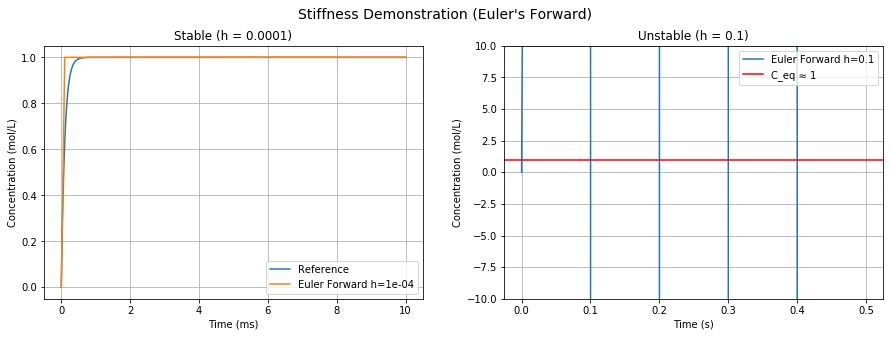

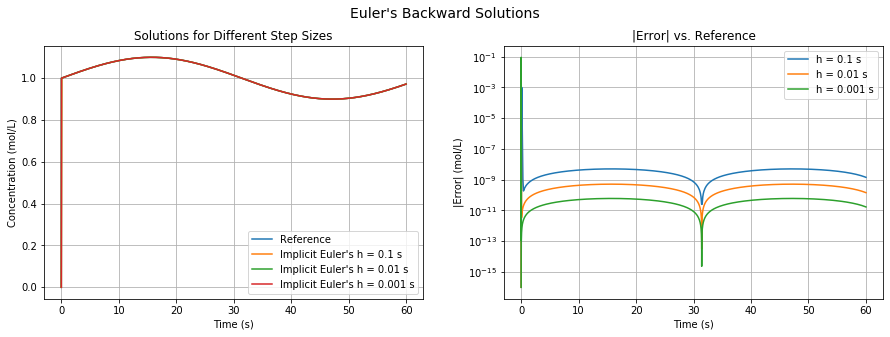

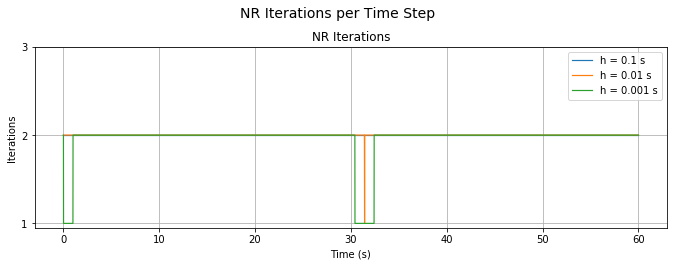

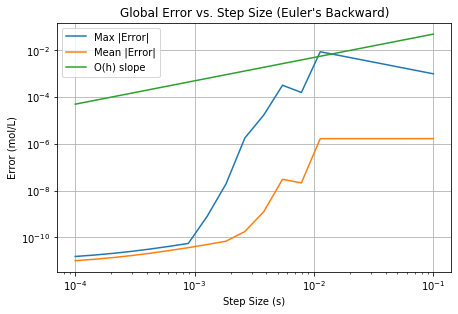

In [2]:
import numpy as np
import matplotlib.pyplot as plt

# Parameters
k   = 1e4
C0  = 0.0
T   = 60.0

# C_eq
def C_eq(t):
    
    return 1.0 + 0.1 * np.sin(0.1 * t)

# dCeq_dt
def dCeq_dt(t):
    
    return 0.01 * np.cos(0.1 * t)

# f
def f(t, C):
    
    return -k * (C - C_eq(t))

# analytical
def analytical_solution(t_array):
    C_anal = np.zeros_like(t_array)
    
    for i, t in enumerate(t_array):
        # transient term
        transient = C0 * np.exp(-k * t)
        # approximation
        qss = C_eq(t) - dCeq_dt(t) / k
        C_anal[i] = transient + qss * (1 - np.exp(-k * t))
    return C_anal

# euler forward
def euler_forward(h, T=T, C0=C0):
    t = np.arange(0, T + h, h)
    C = np.zeros(len(t))
    C[0] = C0
    for n in range(len(t) - 1):
        C[n+1] = C[n] + h * f(t[n], C[n])
    return t, C

# newton raphson
def newton_raphson(t_next, C_n, h, tol=1e-10, max_iter=20):
    
    # G(C) = C - C_n - h*(-k*(C-C_eq(t_{n+1}))
    #      = C(1 + hk) - C_n - hk*C_eq(t_{n+1}) = 0
    
    # dg/dC = 1 + hk (constant)
    
    Ceq_next = C_eq(t_next)
    dGdC = 1.0 + h * k
 
    # initial guess
    C = C_n + h * f(t_next - h, C_n)
 
    iterations = 0
    for i in range(max_iter):
        G = C - C_n - h * f(t_next, C)
        C_new = C - G / dGdC
        iterations += 1
        if abs(C_new - C) < tol:
            return C_new, iterations
        C = C_new
 
    # max iterations reached
    return C, iterations

# euler backward
def euler_backward(h, T=T, C0=C0):
    t = np.arange(0, T + h, h)
    C = np.zeros(len(t))
    C[0] = C0
    iters = []  # NR iterations per step
 
    for n in range(len(t) - 1):
        C[n+1], it = newton_raphson(t[n+1], C[n], h)
        iters.append(it)
 
    return t, C, np.array(iters)

# run
# SECTION 2
# FIG 1
 
fig1, axes = plt.subplots(1, 2, figsize=(13, 5))
fig1.suptitle("Stiffness Demonstration (Euler's Forward)", fontsize=14)

# h < 2/k (stable step size)
h_stable = 1e-4
t_s, C_s = euler_forward(h_stable, T=0.01)
t_ref = np.linspace(0, 0.01, 5000)
C_ref = analytical_solution(t_ref)
axes[0].plot(t_ref * 1e3, C_ref, label='Reference')
axes[0].plot(t_s  * 1e3, C_s, label=f'Euler Forward h={h_stable:.0e}')
axes[0].set_xlabel('Time (ms)')
axes[0].set_ylabel('Concentration (mol/L)')
axes[0].set_title('Stable (h = 0.0001)')
axes[0].legend()
axes[0].grid()

# h > 2/k (unstable step size)
h_unstable = 0.1
t_u, C_u = euler_forward(h_unstable, T=0.5)
axes[1].plot(t_u, C_u, label=f'Euler Forward h={h_unstable}')
axes[1].axhline(1.0, color='red', label='C_eq ≈ 1')
axes[1].set_xlabel('Time (s)')
axes[1].set_ylabel('Concentration (mol/L)')
axes[1].set_title('Unstable (h = 0.1)')
axes[1].set_ylim(-10, 10)
axes[1].legend()
axes[1].grid()

plt.tight_layout(pad=3)
plt.savefig('fig2-1_stiffness.png')
plt.show()

# SECTION 5
# FIG 3

# euler's backward simulation
step_sizes  = [1e-1, 1e-2, 1e-3]
labels      = ['h = 0.1 s', 'h = 0.01 s', 'h = 0.001 s']

t_fine   = np.linspace(0, T, 100_000)
C_exact  = analytical_solution(t_fine)

fig2, axes2 = plt.subplots(1, 2, figsize=(13, 5))
fig2.suptitle("Euler's Backward Solutions", fontsize=14)

axes2[0].plot(t_fine, C_exact, label='Reference')
results = {}
for h, lbl in zip(step_sizes, labels):
    t_b, C_b, iters_b = euler_backward(h)
    results[h] = (t_b, C_b, iters_b)
    axes2[0].plot(t_b, C_b, label=f"Implicit Euler's {lbl}")

axes2[0].set_xlabel('Time (s)')
axes2[0].set_ylabel('Concentration (mol/L)')
axes2[0].set_title('Solutions for Different Step Sizes')
axes2[0].legend()
axes2[0].grid()

# error and references
for h, lbl in zip(step_sizes, labels):
    t_b, C_b, _ = results[h]
    C_ref_h = analytical_solution(t_b)
    err = np.abs(C_b - C_ref_h)
    axes2[1].semilogy(t_b, err + 1e-16, label=lbl)

axes2[1].set_xlabel('Time (s)')
axes2[1].set_ylabel('|Error| (mol/L)')
axes2[1].set_title('|Error| vs. Reference')
axes2[1].legend()
axes2[1].grid()

plt.tight_layout(pad=3)
plt.savefig('fig2-3_backward_solutions.png')
plt.show()

# FIG 4
# nr iterations
fig3, ax3 = plt.subplots(figsize=(10, 4))
fig3.suptitle("NR Iterations per Time Step", fontsize=14)

for h, lbl in zip(step_sizes, labels):
    t_b, C_b, iters_b = results[h]
    ax3.plot(t_b[1:], iters_b, lw=1.2, label=lbl)

ax3.set_xlabel('Time (s)')
ax3.set_ylabel('Iterations')
ax3.set_title('NR Iterations')
ax3.legend(); ax3.grid()
ax3.set_yticks([1, 2, 3])

plt.tight_layout(pad=3)
plt.savefig('fig2-4_nr_iterations.png')

# FIG 5
# errors

h_vals = np.logspace(-4, -1, 20)
max_errors, mean_errors = [], []

for h in h_vals:
    t_b, C_b, _ = euler_backward(h)
    C_ref_h = analytical_solution(t_b)
    mask = t_b > 0.01
    if mask.sum() > 0:
        err = np.abs(C_b[mask] - C_ref_h[mask])
        max_errors.append(np.max(err))
        mean_errors.append(np.mean(err))
    else:
        max_errors.append(np.nan); mean_errors.append(np.nan)

fig4, ax4 = plt.subplots(figsize=(7, 5))
ax4.loglog(h_vals, max_errors,  label='Max |Error|')
ax4.loglog(h_vals, mean_errors, label='Mean |Error|')
# Reference O(h) line
h_ref = np.array([h_vals[0], h_vals[-1]])
ax4.loglog(h_ref, 0.5 * h_ref, label='O(h) slope')
ax4.set_xlabel('Step Size (s)')
ax4.set_ylabel('Error (mol/L)')
ax4.set_title("Global Error vs. Step Size (Euler's Backward)")
ax4.legend()
ax4.grid()
plt.tight_layout(pad=3)
plt.savefig('fig2-5_error_vs_h.png')
plt.show()